In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator


metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
metrics_df["closest_ab_pident"] = metrics_df["closest_ab_pident"].fillna(0)
metrics_df["ubiquitin_pident"] = metrics_df["ubiquitin_pident"].fillna(0)

results_df = pd.read_csv("../data/12k_all_results.csv")
results_df["leah_12k_isup"] = results_df["leah_12k_2fold_threshold"] == "Up"
results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)
# results_df.columns
# results_df["leah_12k_2fold_threshold"].fillna("Not Sig") # I don't think we can fill the rest! and im not even sure this is valid

# # print cols with nan values
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(f"{col}: {metrics_df[col].isna().sum()}")

# # describe each value too
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(metrics_df[col].describe())
#         print()
#         print()

/tmp/ipykernel_2162243/3897468828.py:10: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
/tmp/ipykernel_2162243/3897468828.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


In [2]:
cols = metrics_df.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

mi_df = pd.DataFrame()
for col in cols:
    pre_len = len(metrics_df)
    metrics_df_col = metrics_df[[col]].copy()
    metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
    post_len = len(metrics_df_col)
    X = metrics_df_col[col].values.reshape(-1, 1)
    y = results_df.loc[metrics_df_col.index, "leah_12k_measured"].values
    mi = mutual_info_classif(
        X,
        y,
        random_state=8387234,
        # n_neighbors=5,
        # discrete_features=False,
    )
    sub_df = pd.DataFrame({
        "metric": col,
        "mi_vs_leah_12k_measured": mi,
        "num_non_nan": post_len,
        "num_nan": pre_len - post_len,
    })
    mi_df = pd.concat([mi_df, sub_df], axis=0)


In [3]:
mi_df.sort_values("mi_vs_leah_12k_measured", ascending=False).iloc[0:20]

,metric,mi_vs_leah_12k_measured,num_non_nan,num_nan
0,max_pident_cross_team_hamming,0.225577,12000,0
0,esm2_full_LL_target,0.208398,12000,0
0,esm2_binder_LL_car_target,0.208069,12000,0
0,esm2_binder_LL_target,0.202864,12000,0
0,esm2_pll,0.202590,11968,32
0,esm2_full_LL_car_target,0.195993,12000,0
0,esm2_full_LL_alone,0.193142,12000,0
0,esm2_binder_LL_car,0.190366,12000,0
0,esmfold_plddt_binder_middle,0.176451,12000,0
0,esmfold_plddt_binder_start,0.168775,12000,0


In [13]:
feat_pair = ["esm2_binder_LL_car_target", "boltz_rosetta_A_BC_complex_normalized"]  # replace with two real column names

metrics_df_pair = metrics_df[feat_pair].copy()
metrics_df_pair = metrics_df_pair.dropna()

# # Encode joint states of (feat_a, feat_b) as a single discrete feature
joint_codes, _ = pd.factorize(
    list(zip(metrics_df_pair[feat_pair[0]], metrics_df_pair[feat_pair[1]]))
)

X_pair = joint_codes.reshape(-1, 1)
y_pair = results_df.loc[metrics_df_pair.index, "leah_12k_measured"].values

mi_pair = mutual_info_classif(
    X_pair,
    y_pair,
    random_state=8387234,
    discrete_features=True,
)[0]

mi_pair

/tmp/ipykernel_2162243/359581167.py:7: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  joint_codes, _ = pd.factorize(


np.float64(0.6916040933453587)

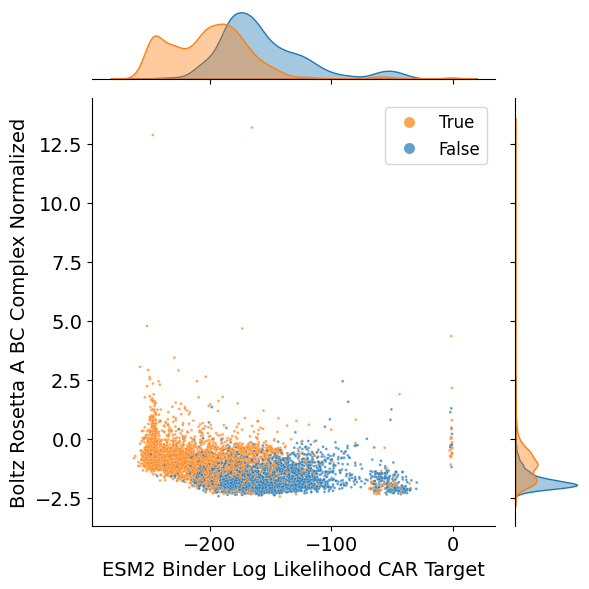

In [42]:
plot_df = metrics_df_pair.join(
    results_df.loc[metrics_df_pair.index, "leah_12k_measured"]
).copy()

# plot_df = plot_df.sort_values("leah_12k_measured", ascending=True)

g = sns.jointplot(
    data=plot_df,
    x=feat_pair[0],
    y=feat_pair[1],
    hue="leah_12k_measured",
    hue_order=[True, False],
    # orange then blue
    palette=["#FF7F0E", "#1F77B4"],
    kind="scatter",
    s=4,
    alpha=0.7,
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
)

g.ax_joint.set_xlabel(feat_pair[0].replace("_", " ").title().replace("Ll", "Log Likelihood").replace("Car", "CAR").replace("Esm", "ESM"), fontsize=14)
g.ax_joint.set_ylabel(feat_pair[1].replace("_", " ").title().replace("Bc", "BC"), fontsize=14)
# xtick size
g.ax_joint.tick_params(axis='x', labelsize=14)
g.ax_joint.tick_params(axis='y', labelsize=14)

# make legend dots bigger
# make legend dots bigger
leg = g.ax_joint.get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

g.ax_joint.legend(handles, labels, markerscale=4, fontsize=12)

plt.tight_layout()
plt.savefig(f"../results/analysis/mi_joint_{feat_pair[0]}_{feat_pair[1]}.png", dpi=300)

In [6]:
# results_df_filtered = results_df[results_df["leah_12k_measured"]].reset_index(drop=True)
# results_df_filtered["leah_12k_2fold_threshold_int"] = results_df_filtered["leah_12k_2fold_threshold"].map({"Up": 1, "Not Sig": 0, "Down": -1})
# metrics_df_filtered = metrics_df.loc[results_df_filtered.index].reset_index(drop=True)

# feat_pair = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", ]  # replace with two real column names

# metrics_df_pair = metrics_df_filtered[feat_pair].copy()
# metrics_df_pair = metrics_df_pair.dropna()

# # Encode joint states of (feat_a, feat_b) as a single discrete feature
# joint_codes, _ = pd.factorize(
#     list(zip(metrics_df_pair[feat_pair[0]], metrics_df_pair[feat_pair[1]]))
# )

# X_pair = joint_codes.reshape(-1, 1)
# y_pair = results_df_filtered.loc[metrics_df_pair.index, "leah_12k_measured"].values

# mi_pair = mutual_info_classif(
#     X_pair,
#     y_pair,
#     random_state=8387234,
#     discrete_features=True,
# )[0]

# mi_pair

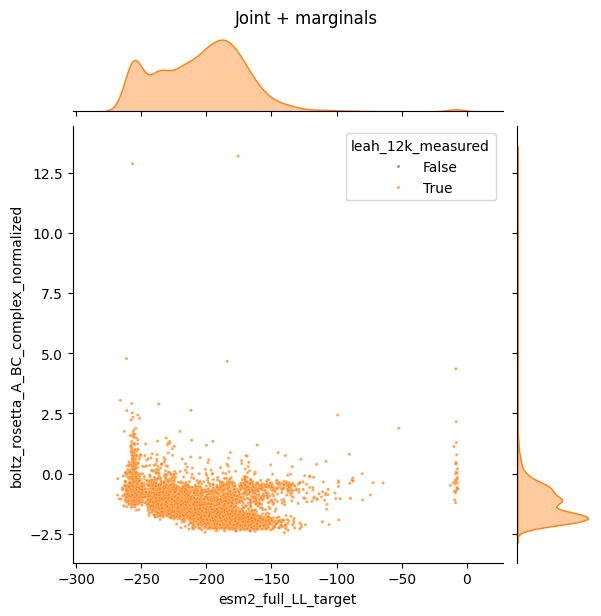

In [7]:
results_filtered_df = results_df[results_df["leah_12k_measured"] == True].copy()
metrics_filtered_df = metrics_df.loc[results_filtered_df.index].copy()
results_filtered_df = results_filtered_df.reset_index(drop=True)
metrics_filtered_df = metrics_filtered_df.reset_index(drop=True)

plot_df = metrics_df_pair.join(
    results_filtered_df.loc[metrics_filtered_df.index, "leah_12k_measured"]
).copy()

plot_df = plot_df.sort_values("leah_12k_measured", ascending=False)

g = sns.jointplot(
    data=plot_df,
    x=feat_pair[0],
    y=feat_pair[1],
    hue="leah_12k_measured",
    hue_order=[False, True],
    kind="scatter",
    s=5,
    alpha=0.7,
    marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
)

g.ax_joint.set_xlabel(feat_pair[0])
g.ax_joint.set_ylabel(feat_pair[1])
g.fig.suptitle("Joint + marginals", y=1.02)
plt.show()

In [8]:
# results_df_filtered = results_df[results_df["leah_12k_measured"]].reset_index(drop=True)
# results_df_filtered["leah_12k_2fold_threshold_int"] = results_df_filtered["leah_12k_2fold_threshold"].map({"Up": 1, "Not Sig": 0, "Down": -1})
# metrics_df_filtered = metrics_df.loc[results_df_filtered.index].reset_index(drop=True)


# # mutual information on leah_12k_2fold_threshold
# mi_df_2fold_threshold = pd.DataFrame()
# for col in cols:
#     pre_len = len(metrics_df_filtered)
#     metrics_df_col = metrics_df_filtered[[col]].copy()
#     metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
#     post_len = len(metrics_df_col)
#     X = metrics_df_col[col].values.reshape(-1, 1)
#     y = results_df_filtered.loc[metrics_df_col.index, "leah_12k_2fold_threshold_int"].values
#     # y = results_df_filtered.loc[metrics_df_col.index, "leah_12k_Significant"].values
#     mi = mutual_info_classif(
#         X,
#         y,
#         random_state=8387234,
#         # n_neighbors=5,
#         # discrete_features=False,
#     )
#     sub_df = pd.DataFrame({
#         "metric": col,
#         "mi_vs_leah_12k_2fold_threshold_int": mi,
#         # "mi_vs_leah_12k_Significant": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })
#     mi_df_2fold_threshold = pd.concat([mi_df_2fold_threshold, sub_df], axis=0)

In [9]:
# mi_df_2fold_threshold.sort_values("mi_vs_leah_12k_2fold_threshold_int", ascending=False).iloc[:20]

In [10]:
# order = ["Up", "Not Sig", "Down"]
# pairs = [("Up", "Not Sig"), ("Down", "Not Sig"), ("Up", "Down")]
# palette = {"Up": "#D97277", "Not Sig": "#BEBEBE", "Down": "#3C53C5"}
